# Classification Data Using Scikit-Learn使用 scikit-learn 進行客戶流失風險（Churn Risk）分類預測，比較 5 種分類演算法的效能。

## 1. 安裝套件

In [1]:
# 使用 uv 套件管理器安裝本專案所需的 Python 套件：
# pandas — 資料框架操作（讀取 CSV、篩選、分組等）
# numpy — 數值運算（陣列操作、數學函式）
# matplotlib — 基礎繪圖（長條圖、散佈圖、3D 圖）
# seaborn — 進階統計視覺化（基於 matplotlib 的美化封裝）
# scikit-learn — 機器學習核心套件（分類器、前處理、評估指標）
# scikit-plot — 快速繪製混淆矩陣等 ML 評估圖表
# !uv pip install pandas numpy matplotlib seaborn scikit-learn scikit-plot

## 2. 匯入函式庫

In [2]:
import sys
import io

# === 資料前處理相關 ===
from sklearn.preprocessing import LabelEncoder, OneHotEncoder  # LabelEncoder：將文字標籤轉為數字（如 High→0, Low→1, Medium→2）
                                                                # OneHotEncoder：將類別特徵轉為 one-hot 向量（如 GENDER=M → [1,0]）
from sklearn.impute import SimpleImputer          # 缺失值填補器，可用眾數（most_frequent）、平均值等策略填補空值
from sklearn.preprocessing import MinMaxScaler    # 最小-最大縮放器（將數值壓縮到 [0,1] 區間），本專案未使用
from sklearn.preprocessing import StandardScaler  # 標準化縮放器（將數值轉為平均值=0、標準差=1 的分佈）
from sklearn.compose import ColumnTransformer, make_column_transformer  # 針對不同欄位套用不同前處理步驟的組合器
from sklearn.pipeline import Pipeline             # 將多個前處理步驟與模型串接成一條流水線，方便統一執行

# === 模型訓練與評估相關 ===
from sklearn.model_selection import train_test_split  # 將資料切分為訓練集與測試集
from sklearn.metrics import accuracy_score, classification_report  # accuracy_score：計算準確率
                                                                    # classification_report：輸出精確率、召回率、F1 分數等完整報告

# === 資料操作 ===
import pandas as pd, numpy as np  # pd：資料框架操作；np：數值陣列運算

# === 視覺化相關 ===
import matplotlib.pyplot as plt          # matplotlib 繪圖主介面
from mpl_toolkits.mplot3d import Axes3D  # 啟用 3D 散佈圖的投影功能
import matplotlib.colors as mcolors      # 顏色工具（本專案未直接使用）
import matplotlib.patches as mpatches    # 用來建立圖例的色塊標籤（如 High/Medium/Low 的顏色說明）
import scikitplot as skplt               # 快速繪製混淆矩陣等機器學習評估圖表

## 3. 載入資料集

In [3]:
# 從 IBM GitHub 讀取客戶資料 CSV 檔（含部分 GENDER 欄位缺失值，用於後續示範缺失值處理）
# 資料集包含客戶的收入、交易天數、交易金額、性別、婚姻狀態、是否有房等欄位
# 目標欄位為 CHURNRISK（客戶流失風險），分為 High / Medium / Low 三個類別
df_churn_pd = pd.read_csv("https://raw.githubusercontent.com/IBM/ml-learning-path-assets/master/data/mergedcustomers_missing_values_GENDER.csv")

# 顯示前 5 筆資料，快速確認欄位名稱與資料格式是否正確
df_churn_pd.head()

,ID,CHURNRISK,GENDER,STATUS,CHILDREN,ESTINCOME,HOMEOWNER,AGE,TOTALDOLLARVALUETRADED,TOTALUNITSTRADED,LARGESTSINGLETRANSACTION,SMALLESTSINGLETRANSACTION,PERCENTCHANGECALCULATION,DAYSSINCELASTLOGIN,DAYSSINCELASTTRADE,NETREALIZEDGAINS_YTD,NETREALIZEDLOSSES_YTD
0,1703,Medium,NaN,M,2,28766.9,N,47,6110.61,58,1527.6525,152.76525,8.70,2,13,0.0000,152.76525
1,1704,Low,NaN,M,2,91272.2,Y,25,26992.70,13,13496.3500,1349.63500,3.25,4,10,1349.6350,0.00000
2,1705,Low,NaN,S,0,73228.3,N,42,22472.25,28,11236.1250,1123.61250,7.00,4,5,1123.6125,0.00000
3,1706,High,M,M,1,64792.3,N,52,13051.31,36,6525.6550,652.56550,9.00,3,6,0.0000,652.56550
4,1707,High,F,S,0,93322.1,Y,40,29922.99,8,14961.4950,1496.14950,2.00,4,9,0.0000,1496.14950


## 4. 資料型態與缺失值檢查

In [4]:
# 印出每個欄位的資料型態（int64 / float64 / object）
# object 通常代表文字型（類別型）欄位，需要額外編碼才能餵給模型
print("The dataset contains columns of the following data types : \n" + str(df_churn_pd.dtypes))
print()

# 印出每個欄位的「非空值」數量
# 若某欄位數量小於總列數，代表該欄位有缺失值（如 GENDER 欄位）
print("The dataset contains following number of records for each of the columns : \n" + str(df_churn_pd.count()))

The dataset contains columns of the following data types : 
ID                             int64
CHURNRISK                        str
GENDER                           str
STATUS                           str
CHILDREN                       int64
ESTINCOME                    float64
HOMEOWNER                        str
AGE                            int64
TOTALDOLLARVALUETRADED       float64
TOTALUNITSTRADED               int64
LARGESTSINGLETRANSACTION     float64
SMALLESTSINGLETRANSACTION    float64
PERCENTCHANGECALCULATION     float64
DAYSSINCELASTLOGIN             int64
DAYSSINCELASTTRADE             int64
NETREALIZEDGAINS_YTD         float64
NETREALIZEDLOSSES_YTD        float64
dtype: object

The dataset contains following number of records for each of the columns : 
ID                           2066
CHURNRISK                    2066
GENDER                       2063
STATUS                       2066
CHILDREN                     2066
ESTINCOME                    2066
HOMEOWNER       

## 5. 客戶流失風險分佈

Each category within the churnrisk column has the following count : 
CHURNRISK
High      983
Low       699
Medium    384
dtype: int64


Text(0, 0.5, 'Frequency')

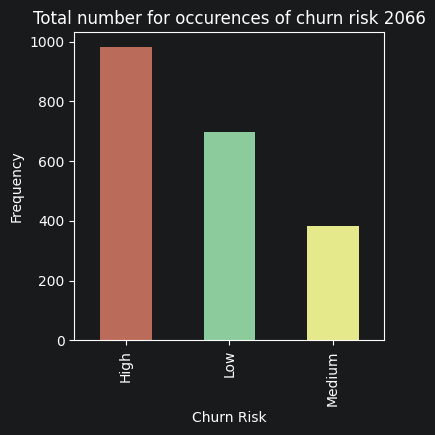

In [5]:
# 印出 CHURNRISK 各類別的樣本數量（High / Medium / Low 各有幾筆）
# 用來觀察資料是否有「類別不平衡」的問題（某類別樣本數遠少於其他類別）
print("Each category within the churnrisk column has the following count : ")
print(df_churn_pd.groupby(['CHURNRISK']).size())

# 繪製長條圖，視覺化各流失風險類別的數量分佈
index = ['High','Medium','Low']
churn_plot = df_churn_pd['CHURNRISK'].value_counts(sort=True, ascending=False).plot(
    kind='bar',          # 圖表類型：長條圖
    figsize=(4,4),       # 圖表尺寸：4×4 吋
    title="Total number for occurences of churn risk " + str(df_churn_pd['CHURNRISK'].count()),  # 標題顯示總樣本數
    color=['#BB6B5A','#8CCB9B','#E5E88B']  # 三個類別分別用紅棕色、綠色、黃色表示
)
churn_plot.set_xlabel("Churn Risk")   # X 軸標籤：流失風險類別
churn_plot.set_ylabel("Frequency")     # Y 軸標籤：出現次數

## 6. 移除不需要的欄位

In [6]:
# 移除 ID 欄位：ID 只是客戶編號，對預測流失風險毫無幫助
# 若保留 ID，模型可能會「記住」特定 ID 對應的標籤，導致過擬合（overfitting）
df_churn_pd = df_churn_pd.drop(['ID'], axis=1)

# 確認 ID 欄位已被移除
df_churn_pd.head()

,CHURNRISK,GENDER,STATUS,CHILDREN,ESTINCOME,HOMEOWNER,AGE,TOTALDOLLARVALUETRADED,TOTALUNITSTRADED,LARGESTSINGLETRANSACTION,SMALLESTSINGLETRANSACTION,PERCENTCHANGECALCULATION,DAYSSINCELASTLOGIN,DAYSSINCELASTTRADE,NETREALIZEDGAINS_YTD,NETREALIZEDLOSSES_YTD
0,Medium,NaN,M,2,28766.9,N,47,6110.61,58,1527.6525,152.76525,8.70,2,13,0.0000,152.76525
1,Low,NaN,M,2,91272.2,Y,25,26992.70,13,13496.3500,1349.63500,3.25,4,10,1349.6350,0.00000
2,Low,NaN,S,0,73228.3,N,42,22472.25,28,11236.1250,1123.61250,7.00,4,5,1123.6125,0.00000
3,High,M,M,1,64792.3,N,52,13051.31,36,6525.6550,652.56550,9.00,3,6,0.0000,652.56550
4,High,F,S,0,93322.1,Y,40,29922.99,8,14961.4950,1496.14950,2.00,4,9,0.0000,1496.14950


## 7. 類別特徵前處理

In [7]:
# 定義需要特殊處理的「類別型」欄位：性別、婚姻狀態、是否有房
# 這些欄位是文字（如 M/F、S/M、Y/N），模型無法直接處理，需要轉換成數值
categoricalColumns = ['GENDER', 'STATUS', 'HOMEOWNER']

print("Categorical columns : ")
print(categoricalColumns)

# 步驟一：缺失值填補 — 用「眾數」（出現最多次的值）填補空值
# 例如 GENDER 欄位有缺失值，若 M 出現最多次，就用 M 填補
impute_categorical = SimpleImputer(strategy="most_frequent")

# 步驟二：One-Hot 編碼 — 將每個類別值展開成獨立的 0/1 欄位
# 例如 GENDER 有 M、F 兩個值 → 展開為 GENDER_M 和 GENDER_F 兩欄
# handle_unknown='ignore' 表示遇到訓練時沒見過的新類別值時，不報錯而是全部填 0
onehot_categorical = OneHotEncoder(handle_unknown='ignore')

# 將填補與編碼兩個步驟串接成 Pipeline，確保執行順序正確：先填補 → 再編碼
categorical_transformer = Pipeline(steps=[('impute', impute_categorical), ('onehot', onehot_categorical)])

Categorical columns : 
['GENDER', 'STATUS', 'HOMEOWNER']


## 8. 數值特徵前處理

In [8]:
# 自動篩選出所有數值型欄位（int 或 float 型態）
# 包含 ESTINCOME（預估收入）、DAYSSINCELASTTRADE（距上次交易天數）、TOTALDOLLARVALUETRADED（交易總金額）等
numericalColumns = df_churn_pd.select_dtypes(include=[float, int]).columns

print("Numerical columns : ")
print(numericalColumns)

# 標準化縮放器：將每個數值欄位轉為「平均值=0、標準差=1」的標準常態分佈
# 為什麼要標準化？因為 KNN 和 SVM 等演算法基於「距離」計算，
# 若收入是萬元等級、天數是百元等級，收入會主導距離計算，標準化可消除量綱差異
scaler_numerical = StandardScaler()

# 數值型欄位的前處理 Pipeline（目前只有標準化一步）
numerical_transformer = Pipeline(steps=[('scale', scaler_numerical)])

Numerical columns : 
Index(['CHILDREN', 'ESTINCOME', 'AGE', 'TOTALDOLLARVALUETRADED',
       'TOTALUNITSTRADED', 'LARGESTSINGLETRANSACTION',
       'SMALLESTSINGLETRANSACTION', 'PERCENTCHANGECALCULATION',
       'DAYSSINCELASTLOGIN', 'DAYSSINCELASTTRADE', 'NETREALIZEDGAINS_YTD',
       'NETREALIZEDLOSSES_YTD'],
      dtype='str')


## 9. 建立 ColumnTransformer

In [9]:
# ColumnTransformer 可以對不同欄位套用不同的前處理流程

# 版本 1：只處理類別型欄位，數值型欄位保持原樣（remainder="passthrough"）
# 適用於樸素貝氏（Naive Bayes）分類器，因為 MultinomialNB 要求輸入為非負值，
# 標準化後的數值可能出現負數，所以數值欄位不做標準化
preprocessorForCategoricalColumns = ColumnTransformer(
    transformers=[('cat', categorical_transformer, categoricalColumns)],  # 只對類別欄位做 填補+One-Hot
    remainder="passthrough")  # 其餘欄位（數值型）直接保留不處理

# 版本 2：類別型做 填補+One-Hot，數值型做標準化 — 全部欄位都處理
# 適用於 KNN、SVM、Random Forest 等需要標準化數值的分類器
preprocessorForAllColumns = ColumnTransformer(
    transformers=[('cat', categorical_transformer, categoricalColumns),   # 類別欄位：填補+One-Hot
                  ('num', numerical_transformer, numericalColumns)],      # 數值欄位：標準化
    remainder="passthrough")  # 其餘欄位直接保留

# 測試版本 1 的轉換結果：類別欄位被展開為 one-hot 向量，數值欄位保持原始數值
df_churn_pd_temp = preprocessorForCategoricalColumns.fit_transform(df_churn_pd)
print("Data after categorical transformation :")
print(df_churn_pd_temp)

# 測試版本 2 的轉換結果：類別欄位展開為 one-hot，數值欄位被標準化為平均值 0、標準差 1
df_churn_pd_temp_2 = preprocessorForAllColumns.fit_transform(df_churn_pd)
print("\nData after all transformations :")
print(df_churn_pd_temp_2)

Data after categorical transformation :
[[1.0 0.0 0.0 ... 13 0.0 152.76525]
 [1.0 0.0 0.0 ... 10 1349.635 0.0]
 [1.0 0.0 0.0 ... 5 1123.6125 0.0]
 ...
 [1.0 0.0 0.0 ... 11 0.0 82.50825]
 [1.0 0.0 0.0 ... 5 930.093 0.0]
 [0.0 1.0 0.0 ... 8 1041.604 0.0]]

Data after all transformations :
[[1.0 0.0 0.0 ... -0.6792731303453047 -0.5106065181930338 'Medium']
 [1.0 0.0 0.0 ... 1.8354629319820521 -0.7959345330293706 'Low']
 [1.0 0.0 0.0 ... 1.4143217110983428 -0.7959345330293706 'Low']
 ...
 [1.0 0.0 0.0 ... -0.6792731303453047 -0.6418293606808149 'Medium']
 [1.0 0.0 0.0 ... 1.053742394902809 -0.7959345330293706 'Low']
 [0.0 1.0 0.0 ... 1.261517632686496 -0.7959345330293706 'Low']]


## 10. 定義特徵與標籤

In [10]:
# 定義特徵矩陣 X：移除目標欄位 CHURNRISK，剩下的所有欄位都是模型的輸入特徵
features = df_churn_pd.drop(['CHURNRISK'], axis=1)

# 取出目標欄位 CHURNRISK（此行建立了 DataFrame，但後續未使用，僅供參考）
label_churn = pd.DataFrame(df_churn_pd, columns=['CHURNRISK'])

# 建立 LabelEncoder，用來將文字標籤轉換為數字
# 因為分類模型的輸出必須是數字，無法直接處理 "High"、"Medium"、"Low" 字串
label_encoder = LabelEncoder()

# 取出目標欄位的原始文字值
label = df_churn_pd['CHURNRISK']

# 將文字標籤編碼為數字：High→0、Low→1、Medium→2（依字母順序排列）
# 後續訓練模型時，y_train / y_test 都會是這組數字
label = label_encoder.fit_transform(label)
print("Encoded value of Churnrisk after applying label encoder : " + str(label))

Encoded value of Churnrisk after applying label encoder : [2 1 1 ... 2 1 1]


## 11. 資料視覺化探索（2D / 3D 散佈圖）

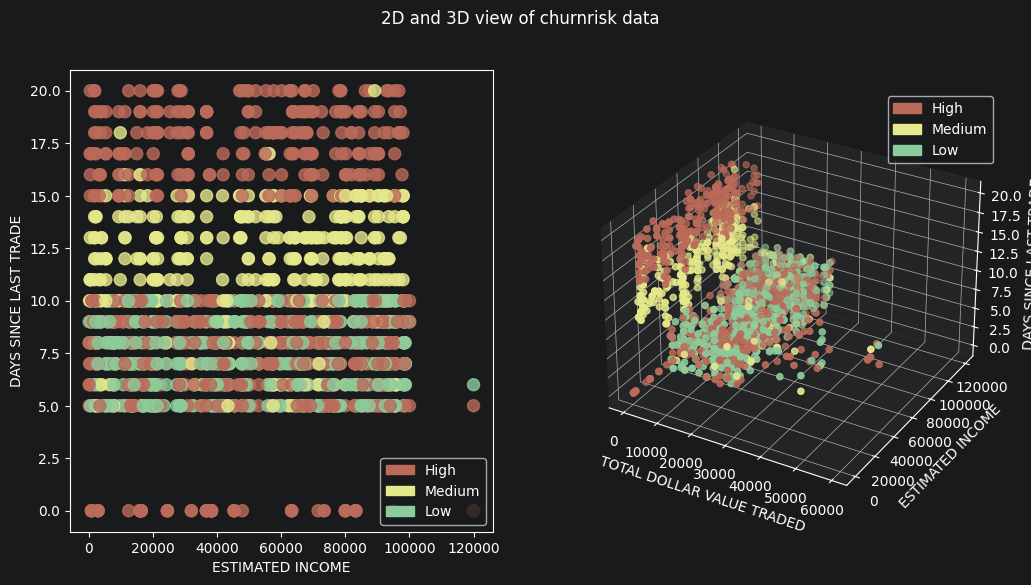

In [11]:
# 設定散佈圖點的大小
area = 75

# 取出三個數值特徵，用於視覺化（觀察不同流失風險類別在特徵空間中的分佈）
x = df_churn_pd['ESTINCOME']               # X 軸：預估收入
y = df_churn_pd['DAYSSINCELASTTRADE']       # Y 軸：距上次交易天數
z = df_churn_pd['TOTALDOLLARVALUETRADED']   # Z 軸：交易總金額（用於 3D 圖）

# 建立圖例色塊，讓讀者知道每種顏色代表哪個流失風險等級
pop_a = mpatches.Patch(color='#BB6B5A', label='High')     # 紅棕色 = 高風險
pop_b = mpatches.Patch(color='#E5E88B', label='Medium')   # 黃色 = 中風險
pop_c = mpatches.Patch(color='#8CCB9B', label='Low')      # 綠色 = 低風險

# 顏色對應函式：根據編碼後的標籤數字，回傳對應的顏色
# 0=High（紅棕）、1=Low（綠）、2=Medium（黃）
def colormap(risk_list):
    cols = []
    for l in risk_list:
        if l == 0:
            cols.append('#BB6B5A')   # High → 紅棕色
        elif l == 2:
            cols.append('#E5E88B')   # Medium → 黃色
        elif l == 1:
            cols.append('#8CCB9B')   # Low → 綠色
    return cols

# 建立 1 列 2 欄的子圖：左邊 2D 散佈圖、右邊 3D 散佈圖
fig = plt.figure(figsize=(12, 6))
fig.suptitle('2D and 3D view of churnrisk data')  # 總標題

# === 左圖：2D 散佈圖（收入 vs 交易天數）===
ax = fig.add_subplot(1, 2, 1)
ax.scatter(x, y, alpha=0.8, c=colormap(label), s=area)  # alpha=0.8 讓點半透明，方便觀察重疊
ax.set_ylabel('DAYS SINCE LAST TRADE')   # Y 軸：距上次交易天數
ax.set_xlabel('ESTIMATED INCOME')         # X 軸：預估收入
plt.legend(handles=[pop_a, pop_b, pop_c]) # 加上顏色圖例

# === 右圖：3D 散佈圖（交易金額 × 收入 × 交易天數）===
# 多一個維度可以觀察到 2D 圖看不到的分群結構
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.scatter(z, x, y, c=colormap(label), marker='o')
ax.set_xlabel('TOTAL DOLLAR VALUE TRADED')  # X 軸：交易總金額
ax.set_ylabel('ESTIMATED INCOME')            # Y 軸：預估收入
ax.set_zlabel('DAYS SINCE LAST TRADE')       # Z 軸：距上次交易天數
plt.legend(handles=[pop_a, pop_b, pop_c])

plt.show()

## 12. 切分訓練與測試資料

In [12]:
# 將資料切分為「訓練集」與「測試集」
# features（X）：輸入特徵；label（y）：目標標籤
# 預設比例為 75% 訓練、25% 測試
# random_state=0 固定隨機種子，確保每次執行切分結果一致（可重現）
X_train, X_test, y_train, y_test = train_test_split(features, label, random_state=0)

# 印出訓練集與測試集的維度，確認切分是否正確
# 例如：X_train.shape = (750, 10) 表示 750 筆訓練樣本、10 個特徵
print("Dimensions of datasets that will be used for training : Input features" + str(X_train.shape) +
      " Output label" + str(y_train.shape))
print("Dimensions of datasets that will be used for testing : Input features" + str(X_test.shape) +
      " Output label" + str(y_test.shape))

Dimensions of datasets that will be used for training : Input features(1549, 15) Output label(1549,)
Dimensions of datasets that will be used for testing : Input features(517, 15) Output label(517,)


## 13. 定義輔助函式

In [13]:
# ============================================================
# 定義三個輔助函式，供後續五種模型的評估與視覺化重複使用
# ============================================================

# --- 顏色對應函式（與前面相同，重新定義以確保此區段獨立可用）---
# 將編碼後的數字標籤對應到顏色：0=High（紅棕）、1=Low（綠）、2=Medium（黃）
def colormap(risk_list):
    cols = []
    for l in risk_list:
        if l == 0:
            cols.append('#BB6B5A')   # High → 紅棕色
        elif l == 2:
            cols.append('#E5E88B')   # Medium → 黃色
        elif l == 1:
            cols.append('#8CCB9B')   # Low → 綠色
    return cols

# --- 2D 散佈圖比較函式：並排顯示「實際值」與「預測值」---
# 讓我們一眼看出模型預測與真實結果的差異
def two_d_compare(y_test, y_pred, model_name):
    area = (12 * np.random.rand(40))**2  # 隨機產生點的大小（純裝飾用途）
    plt.subplots(ncols=2, figsize=(10, 4))  # 建立 1 列 2 欄的子圖
    # 標題同時顯示模型名稱與準確率，方便快速比較
    plt.suptitle('Actual vs Predicted data : ' + model_name + '. Accuracy : %.2f' % accuracy_score(y_test, y_pred))

    # 左圖：測試集的「真實」流失風險分佈
    plt.subplot(121)
    plt.scatter(X_test['ESTINCOME'], X_test['DAYSSINCELASTTRADE'], alpha=0.8, c=colormap(y_test))
    plt.title('Actual')
    plt.legend(handles=[pop_a, pop_b, pop_c])

    # 右圖：模型的「預測」流失風險分佈
    # 若預測正確，兩張圖的顏色分佈應該非常接近
    plt.subplot(122)
    plt.scatter(X_test['ESTINCOME'], X_test['DAYSSINCELASTTRADE'], alpha=0.8, c=colormap(y_pred))
    plt.title('Predicted')
    plt.legend(handles=[pop_a, pop_b, pop_c])

    plt.show()

# 取出測試集的三個特徵，供 3D 圖使用
x = X_test['TOTALDOLLARVALUETRADED']   # 交易總金額
y = X_test['ESTINCOME']                 # 預估收入
z = X_test['DAYSSINCELASTTRADE']        # 距上次交易天數

# 圖例色塊（與前面相同）
pop_a = mpatches.Patch(color='#BB6B5A', label='High')     # 高風險
pop_b = mpatches.Patch(color='#E5E88B', label='Medium')   # 中風險
pop_c = mpatches.Patch(color='#8CCB9B', label='Low')      # 低風險

# --- 3D 散佈圖比較函式：並排顯示「實際值」與「預測值」的 3D 視角 ---
# 提供比 2D 更豐富的空間資訊，有助觀察模型在高維空間的預測行為
def three_d_compare(y_test, y_pred, model_name):
    fig = plt.figure(figsize=(12, 10))
    fig.suptitle('Actual vs Predicted (3D) data : ' + model_name + '. Accuracy : %.2f' % accuracy_score(y_test, y_pred))

    # 左圖：3D 真實值
    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(x, y, z, c=colormap(y_test), marker='o')
    ax.set_xlabel('TOTAL DOLLAR VALUE TRADED')
    ax.set_ylabel('ESTIMATED INCOME')
    ax.set_zlabel('DAYS SINCE LAST TRADE')
    plt.legend(handles=[pop_a, pop_b, pop_c])
    plt.title('Actual')

    # 右圖：3D 預測值
    ax = fig.add_subplot(122, projection='3d')
    ax.scatter(x, y, z, c=colormap(y_pred), marker='o')
    ax.set_xlabel('TOTAL DOLLAR VALUE TRADED')
    ax.set_ylabel('ESTIMATED INCOME')
    ax.set_zlabel('DAYS SINCE LAST TRADE')
    plt.legend(handles=[pop_a, pop_b, pop_c])
    plt.title('Predicted')

    plt.show()

# --- 模型評估函式：印出解碼後的標籤值 + 繪製混淆矩陣 ---
# 混淆矩陣（Confusion Matrix）可以看出模型把哪些類別搞混了
# 對角線上的數字越大越好（代表預測正確），非對角線越小越好（代表誤判）
def model_metrics(y_test, y_pred):
    print("Decoded values of Churnrisk after applying inverse of label encoder : " + str(np.unique(y_pred)))
    skplt.metrics.plot_confusion_matrix(y_test, y_pred, text_fontsize="small", cmap='Greens', figsize=(6, 4))
    plt.show()

## 14. 樸素貝氏分類器（Naive Bayes）— 建模與預測

In [14]:
# ============================================================
# 模型 1：樸素貝氏分類器（Multinomial Naive Bayes）
# ============================================================
# 核心原理：基於貝氏定理，假設所有特徵之間「條件獨立」
# P(類別|特徵) ∝ P(特徵|類別) × P(類別)
# Multinomial 版本適合用於「計數型」或「非負」特徵（如 one-hot 編碼後的值）
# 優點：訓練速度極快、不容易過擬合；缺點：特徵獨立假設在實際資料中通常不成立

from sklearn.naive_bayes import MultinomialNB

model_name = 'Naive Bayes Classifier'

# alpha=1.0：拉普拉斯平滑參數，避免某特徵在某類別中機率為 0 的問題
# fit_prior=True：從訓練資料中學習各類別的先驗機率（而非假設均勻分佈）
nbClassifier = MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True)

# 建立 Pipeline：先做類別欄位前處理（填補+One-Hot），再接樸素貝氏分類器
# 注意：這裡用 preprocessorForCategoricalColumns（不標準化數值），
# 因為 MultinomialNB 要求輸入值 ≥ 0，標準化會產生負數
nb_model = Pipeline(steps=[('preprocessor', preprocessorForCategoricalColumns), ('classifier', nbClassifier)])

# 用訓練集擬合模型（學習各特徵在各類別下的機率分佈）
nb_model.fit(X_train, y_train)

# 用測試集進行預測，產生每筆測試資料的預測類別（0/1/2）
y_pred_nb = nb_model.predict(X_test)

## 15. 樸素貝氏分類器 — 評估與視覺化

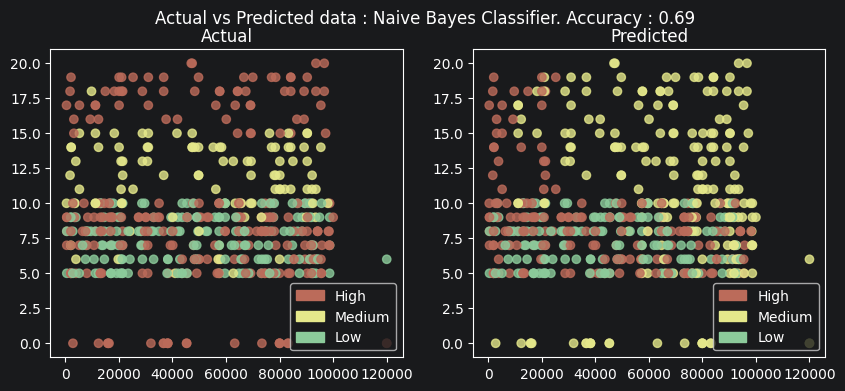

Decoded values of Churnrisk after applying inverse of label encoder : ['High' 'Low' 'Medium']


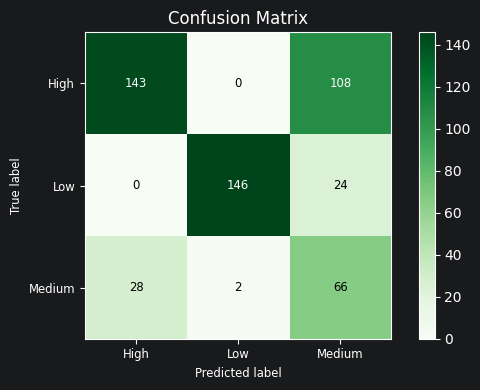

In [15]:
# 繪製 2D 散佈圖：比較樸素貝氏的預測結果與真實值
two_d_compare(y_test, y_pred_nb, model_name)

# 將數字標籤反轉回文字（0→High、1→Low、2→Medium），方便混淆矩陣顯示可讀的類別名稱
y_test = label_encoder.inverse_transform(y_test)
y_pred_nb = label_encoder.inverse_transform(y_pred_nb)

# 繪製混淆矩陣，觀察樸素貝氏在各類別上的預測表現
model_metrics(y_test, y_pred_nb)

## 16. 邏輯迴歸分類器（Logistic Regression）— 建模與預測

In [16]:
# ============================================================
# 模型 2：邏輯迴歸分類器（Logistic Regression）
# ============================================================
# 核心原理：用 sigmoid 函式將線性組合的結果壓縮到 [0,1] 區間，輸出各類別的機率
# 雖然名稱有「迴歸」，但實際上是分類演算法（歷史命名問題）
# multi_class='auto' 會自動選擇 one-vs-rest 或 multinomial 策略
# 優點：可解釋性強、訓練快；缺點：只能學到線性決策邊界

from sklearn.linear_model import LogisticRegression

model_name = "Logistic Regression Classifier"

# solver='lbfgs'：使用 L-BFGS 最佳化演算法（適合中小型資料集）
# max_iter=1000：最大迭代次數，確保模型收斂（預設 100 有時不夠）
# random_state=0：固定隨機種子以確保結果可重現
logisticRegressionClassifier = LogisticRegression(random_state=0, solver='lbfgs', max_iter=1000)

# 建立 Pipeline：全欄位前處理（含數值標準化）+ 邏輯迴歸分類器
# 邏輯迴歸對特徵尺度敏感，必須使用 preprocessorForAllColumns（包含 StandardScaler）
lrc_model = Pipeline(steps=[('preprocessorAll', preprocessorForAllColumns),
                            ('classifier', logisticRegressionClassifier)])

# 訓練模型
lrc_model.fit(X_train, y_train)

# 預測測試集
y_pred_lrc = lrc_model.predict(X_test)

## 17. 邏輯迴歸分類器 — 評估與視覺化

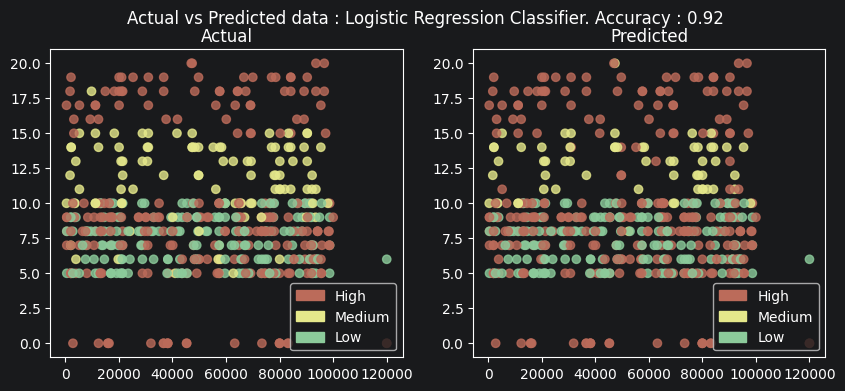

Decoded values of Churnrisk after applying inverse of label encoder : ['High' 'Low' 'Medium']


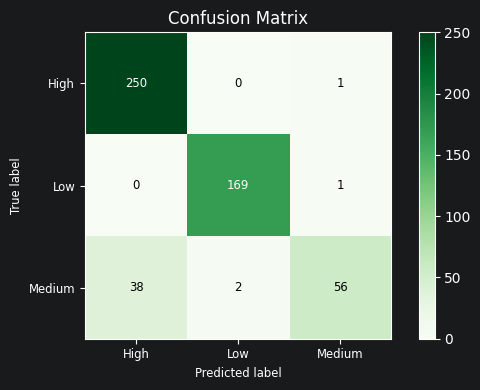

In [17]:
# 上一個 cell 結束時 y_test 是文字標籤（因為在 NB 評估時做了 inverse_transform）
# 這裡要先轉回數字，才能與 y_pred_lrc（數字格式）一起繪製 2D 比較圖
y_test = label_encoder.transform(y_test)

# 繪製 2D 散佈圖：比較邏輯迴歸的預測結果與真實值
two_d_compare(y_test, y_pred_lrc, model_name)

# 再轉回文字標籤，用於混淆矩陣的顯示
y_test = label_encoder.inverse_transform(y_test)
y_pred_lrc = label_encoder.inverse_transform(y_pred_lrc)

# 繪製混淆矩陣
model_metrics(y_test, y_pred_lrc)

## 18. K-近鄰分類器（K-Nearest Neighbors）— 建模與預測

In [18]:
# ============================================================
# 模型 3：K-近鄰分類器（K-Nearest Neighbors, KNN）
# ============================================================
# 核心原理：對每筆測試資料，找出訓練集中「距離最近」的 K 個鄰居，
# 以多數決（majority vote）決定預測類別
# 優點：直覺簡單、無需假設資料分佈；缺點：預測速度慢（需計算所有距離）、對特徵尺度敏感

from sklearn.neighbors import KNeighborsClassifier

model_name = "K-Nearest Neighbor Classifier"

# n_neighbors=5：找最近的 5 個鄰居進行投票
# metric='minkowski', p=2：使用歐幾里得距離（Minkowski 距離在 p=2 時等同歐氏距離）
knnClassifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

# 建立 Pipeline：使用 preprocessorForAllColumns（類別 One-Hot + 數值標準化）
# KNN 基於距離計算，所以「必須」標準化數值特徵，否則量綱大的欄位會主導距離
knn_model = Pipeline(steps=[('preprocessorAll', preprocessorForAllColumns), ('classifier', knnClassifier)])

# 訓練模型（KNN 的「訓練」其實只是把資料存起來，真正的計算在預測時發生）
knn_model.fit(X_train, y_train)

# 預測測試集
y_pred_knn = knn_model.predict(X_test)

## 19. K-近鄰分類器 — 評估與視覺化

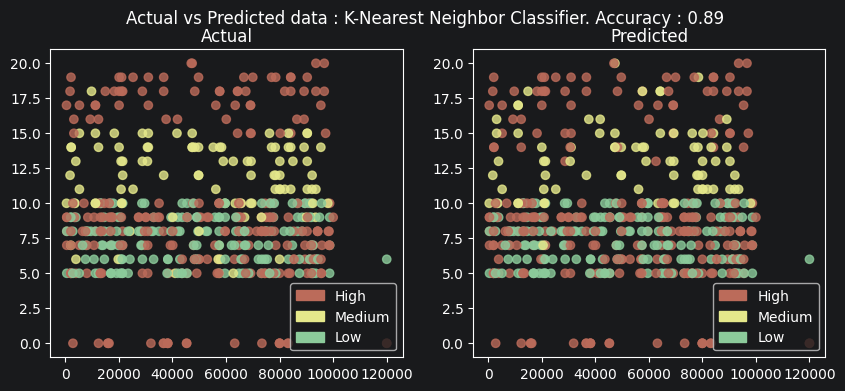

Decoded values of Churnrisk after applying inverse of label encoder : ['High' 'Low' 'Medium']


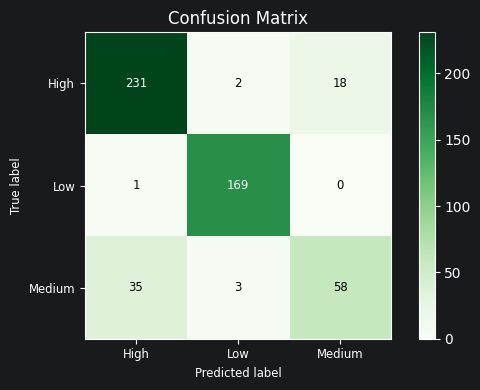

In [19]:
# 將 y_test 轉回數字格式，以便繪製 2D 比較圖
y_test = label_encoder.transform(y_test)

# 繪製 2D 散佈圖：比較 KNN 的預測結果與真實值
two_d_compare(y_test, y_pred_knn, model_name)

# 轉回文字標籤，用於混淆矩陣
y_test = label_encoder.inverse_transform(y_test)
y_pred_knn = label_encoder.inverse_transform(y_pred_knn)

# 繪製混淆矩陣
model_metrics(y_test, y_pred_knn)

## 20. 核支援向量機分類器（Kernel SVM）— 建模與預測

In [20]:
# ============================================================
# 模型 4：核支援向量機分類器（Kernel SVM）
# ============================================================
# 核心原理：在高維空間中找到一個「最大間隔超平面」來分隔不同類別
# kernel='rbf'（徑向基函式）可以學到「非線性」決策邊界
# RBF 核會將資料隱式映射到無限維空間，讓原本線性不可分的資料變得可分
# 優點：處理非線性問題能力強；缺點：大資料集訓練慢、難以解釋

from sklearn.svm import SVC

model_name = 'Kernel SVM Classifier'

# kernel='rbf'：使用高斯徑向基函式核（最常用的非線性核函式）
# gamma='auto'：核函式的寬度參數，auto 表示 gamma = 1 / n_features
svmClassifier = SVC(kernel='rbf', gamma='auto')

# 建立 Pipeline：類別 One-Hot + 數值標準化 + SVM 分類器
# SVM 也基於距離計算，「必須」標準化數值特徵
svm_model = Pipeline(steps=[('preprocessorAll', preprocessorForAllColumns), ('classifier', svmClassifier)])

# 訓練模型
svm_model.fit(X_train, y_train)

# 預測測試集
y_pred_svm = svm_model.predict(X_test)

## 21. 核支援向量機分類器 — 評估與視覺化

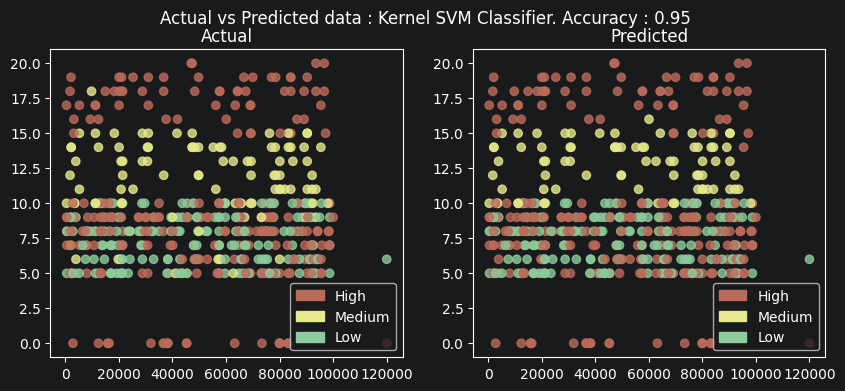

Decoded values of Churnrisk after applying inverse of label encoder : ['High' 'Low' 'Medium']


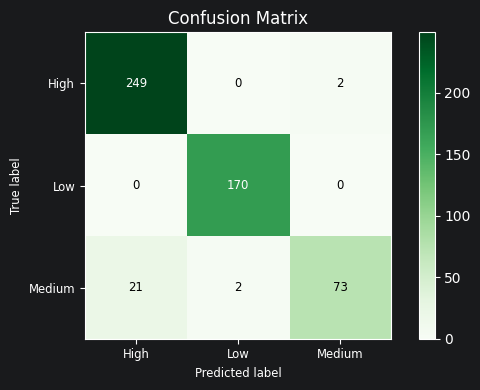

In [21]:
# 將 y_test 轉回數字格式
y_test = label_encoder.transform(y_test)

# 繪製 2D 散佈圖：比較 SVM 的預測結果與真實值
two_d_compare(y_test, y_pred_svm, model_name)

# 轉回文字標籤
y_test = label_encoder.inverse_transform(y_test)
y_pred_svm = label_encoder.inverse_transform(y_pred_svm)

# 繪製混淆矩陣
model_metrics(y_test, y_pred_svm)

## 22. 隨機森林分類器（Random Forest）— 建模與預測

In [22]:
# ============================================================
# 模型 5：隨機森林分類器（Random Forest）
# ============================================================
# 核心原理：建立多棵「決策樹」，每棵樹只看隨機抽樣的部分特徵與部分資料，
# 最終以多數決整合所有樹的預測結果（集成學習 Ensemble Learning）
# 隨機性來源：(1) 每棵樹用 bootstrap 抽樣的資料子集 (2) 每次分裂只考慮隨機特徵子集
# 優點：不容易過擬合、可處理高維資料、能輸出特徵重要度；缺點：模型較大、訓練時間較長

from sklearn.ensemble import RandomForestClassifier

model_name = "Random Forest Classifier"

# n_estimators=100：建立 100 棵決策樹
# max_depth=2：每棵樹最多只能長到 2 層深度（限制複雜度，防止過擬合）
# random_state=0：固定隨機種子
randomForestClassifier = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=0)

# 建立 Pipeline：類別 One-Hot + 數值標準化 + 隨機森林分類器
# 雖然決策樹本身不需要標準化，但為了與其他模型一致，這裡仍使用 preprocessorForAllColumns
rfc_model = Pipeline(steps=[('preprocessorAll', preprocessorForAllColumns), ('classifier', randomForestClassifier)])

# 訓練模型（建立 100 棵決策樹）
rfc_model.fit(X_train, y_train)

# 預測測試集（每棵樹投票，取多數決結果）
y_pred_rfc = rfc_model.predict(X_test)

## 23. 隨機森林分類器 — 評估與視覺化

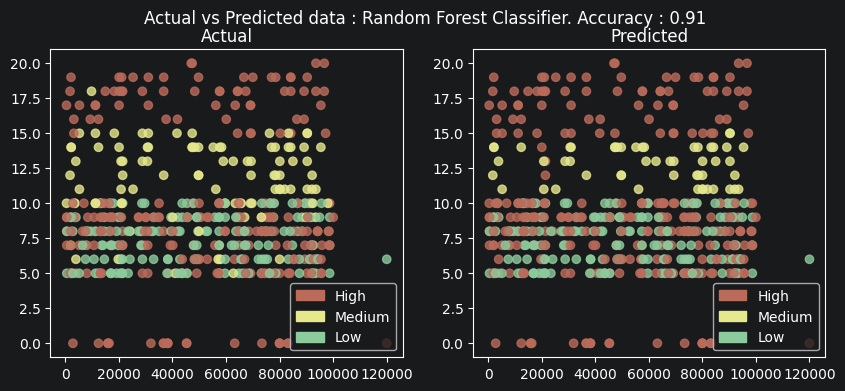

Decoded values of Churnrisk after applying inverse of label encoder : ['High' 'Low' 'Medium']


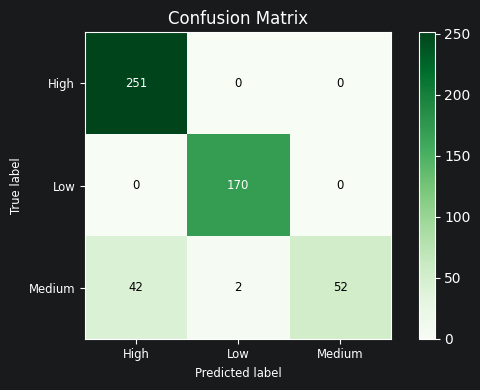

In [23]:
# 將 y_test 轉回數字格式
y_test = label_encoder.transform(y_test)

# 繪製 2D 散佈圖：比較隨機森林的預測結果與真實值
two_d_compare(y_test, y_pred_rfc, model_name)

# 轉回文字標籤
y_test = label_encoder.inverse_transform(y_test)
y_pred_rfc = label_encoder.inverse_transform(y_pred_rfc)

# 繪製混淆矩陣
model_metrics(y_test, y_pred_rfc)

## 24. 模型效能比較

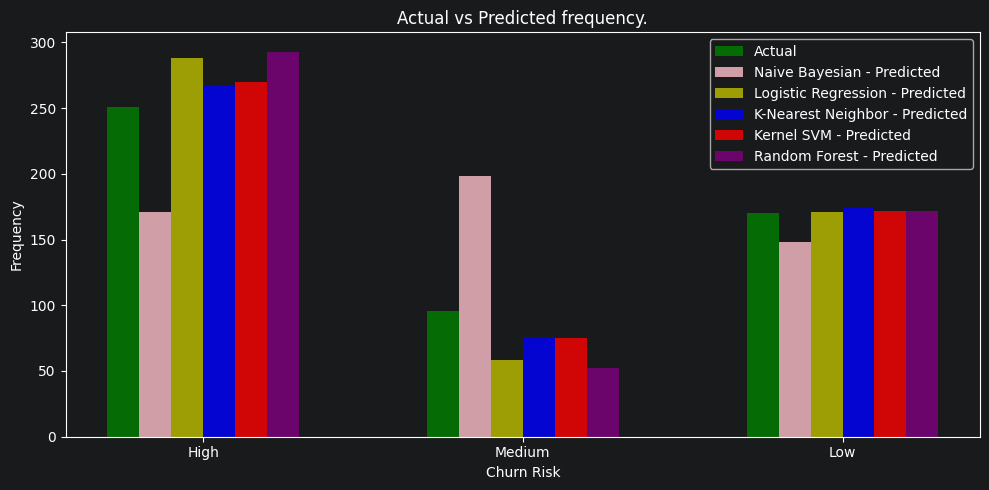

In [24]:
# ============================================================
# 五種模型的效能總比較：用分組長條圖比較各模型預測的類別數量分佈
# ============================================================

# 計算測試集中各類別的「真實」數量
# np.unique 回傳排序後的唯一值與對應次數：[High, Low, Medium] → 索引 [0, 1, 2]
# 但圖表要按 High, Medium, Low 排列，所以用 (索引0, 索引2, 索引1) 重新排序
uniqueValues, occurCount = np.unique(y_test, return_counts=True)
frequency_actual = (occurCount[0], occurCount[2], occurCount[1])  # (High, Medium, Low)

# 計算 KNN 預測的各類別數量
uniqueValues, occurCount = np.unique(y_pred_knn, return_counts=True)
frequency_predicted_knn = (occurCount[0], occurCount[2], occurCount[1])

# 計算隨機森林預測的各類別數量
uniqueValues, occurCount = np.unique(y_pred_rfc, return_counts=True)
frequency_predicted_rfc = (occurCount[0], occurCount[2], occurCount[1])

# 計算邏輯迴歸預測的各類別數量
uniqueValues, occurCount = np.unique(y_pred_lrc, return_counts=True)
frequency_predicted_lrc = (occurCount[0], occurCount[2], occurCount[1])

# 計算 SVM 預測的各類別數量
uniqueValues, occurCount = np.unique(y_pred_svm, return_counts=True)
frequency_predicted_svm = (occurCount[0], occurCount[2], occurCount[1])

# 計算樸素貝氏預測的各類別數量
uniqueValues, occurCount = np.unique(y_pred_nb, return_counts=True)
frequency_predicted_nb = (occurCount[0], occurCount[2], occurCount[1])

# === 繪製分組長條圖 ===
n_groups = 3  # 三個類別：High, Medium, Low
fig, ax = plt.subplots(figsize=(10, 5))
index = np.arange(n_groups)  # X 軸位置：[0, 1, 2]
bar_width = 0.1              # 每根長條的寬度
opacity = 0.8                # 透明度

# 依序繪製 6 組長條（真實值 + 5 種模型的預測值），每組偏移一個 bar_width
rects1 = plt.bar(index, frequency_actual, bar_width, alpha=opacity, color='g', label='Actual')
rects2 = plt.bar(index + bar_width, frequency_predicted_nb, bar_width, alpha=opacity, color='pink', label='Naive Bayesian - Predicted')
rects3 = plt.bar(index + bar_width*2, frequency_predicted_lrc, bar_width, alpha=opacity, color='y', label='Logistic Regression - Predicted')
rects4 = plt.bar(index + bar_width*3, frequency_predicted_knn, bar_width, alpha=opacity, color='b', label='K-Nearest Neighbor - Predicted')
rects5 = plt.bar(index + bar_width*4, frequency_predicted_svm, bar_width, alpha=opacity, color='red', label='Kernel SVM - Predicted')
rects6 = plt.bar(index + bar_width*5, frequency_predicted_rfc, bar_width, alpha=opacity, color='purple', label='Random Forest - Predicted')

plt.xlabel('Churn Risk')     # X 軸：流失風險類別
plt.ylabel('Frequency')       # Y 軸：數量
plt.title('Actual vs Predicted frequency.')  # 標題
ax.set_xticks(index + bar_width * 2.5)      # 將 X 軸刻度置中於 6 根長條的中間
ax.set_xticklabels(('High', 'Medium', 'Low'))  # X 軸標籤
plt.legend()  # 顯示圖例

plt.tight_layout()  # 自動調整版面，避免標籤被裁切
plt.show()

# 關鍵觀察：若某模型的長條高度與綠色（Actual）差距越小，代表該模型預測越準確
# 特別注意 Medium 類別 — 由於樣本數較少，多數模型在此類別的預測表現較差

## 結論整體而言，Medium 類別的預測準確度較低，可能原因是 Medium 類別的樣本數遠少於 High 和 Low，導致模型學習不足。

<p><font size=-1 color=gray>&copy; Copyright 2019 IBM Corp. All Rights Reserved.<p>Licensed under the Apache License, Version 2.0 (the "License"); you may not use this fileexcept in compliance with the License. You may obtain a copy of the License athttps://www.apache.org/licenses/LICENSE-2.0Unless required by applicable law or agreed to in writing, software distributed under theLicense is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, eitherexpress or implied. See the License for the specific language governing permissions andlimitations under the License.</font></p>